# Reconstrucción de la DSA: método espectral, suavizado y artefactos

## Objetivo

Este notebook reúne en un único experimento las comparaciones realizadas hasta
ahora:

- Welch frente a transformada wavelet continua Morlet.
- Media móvil causal `rolling` frente a suavizado exponencial `ewm`.
- Barrido de desplazamientos temporales entre 0 y 30 segundos.
- Máscara base de la aplicación frente a una máscara ampliada con los flags
  oficiales de artefacto contenidos en `.ara/ARTF2`.

La referencia es siempre la matriz original `.f_a`. No se modifica el código de
la aplicación.

## Archivos utilizados

Para cada registro se emplean todos los archivos relevantes de la exportación:

- `.r2a` o `.r4a`: señal EEG cruda.
- `.h_a`: canales, frecuencia de muestreo, pendiente y offset.
- `.t_a`: inicio temporal de la onda cruda.
- `.o_a`: tamaño declarado del archivo raw y offset temporal.
- `.spa`: variables procesadas, `SpSmooth`, `LoFilter`, SQI y TOTPOW.
- `.f_a`: DSA original utilizada como referencia.
- `.ara`: un entero de 32 bits por canal y segundo con los flags de artefacto.
- `.e_a`: alarmas y errores registrados durante la sesión.
- `.m_a`: revisiones del equipo y comprobaciones puntuales de impedancia.

Los archivos `.e_a`, `.m_a` y `.o_a` se utilizan como diagnóstico y
verificación. La máscara temporal por segundo procede de `.spa`, `.ara` y de la
onda cruda, porque son las fuentes que pueden alinearse de forma inequívoca con
cada instante de la DSA.

## Condiciones comunes

- Canal 1 en unilateral.
- Canal 1 izquierdo y canal 3 derecho en bilateral.
- Filtro pasa-altos causal determinado por `LoFilter`.
- Ventana Hann de 2 segundos.
- Avance de 1 segundo.
- Eliminación de la media con `detrend="constant"` en Welch.
- PSD en µV²/Hz.
- Frecuencias de 0,5 a 30 Hz en incrementos de 0,5 Hz.
- Integración de cada bin multiplicando la PSD por 0,5 Hz.
- Conversión a dB respecto a 0,0001 µV RMS.
- Suavizado indicado por `SpSmooth`.
- Shifts entre 0 y 30 segundos.

Se analizan completos `L03041035` y `L05141322`. Del registro largo
`L04301923` se utilizan las dos primeras horas para que el cálculo wavelet sea
reproducible en un tiempo razonable.

In [1]:
from pathlib import Path
import collections
import gc
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from scipy.signal import get_window

APP_DIR = Path(r"C:\Users\usuario\tfg_app")
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

from src.lectura_fa import (
    cargar_fa_bilateral_completo_desde_ruta,
    cargar_fa_unilateral_desde_ruta,
)
from src.lectura_spa import (
    cargar_spa_bilateral_desde_ruta,
    cargar_spa_unilateral_desde_ruta,
    preparar_dsa_bilateral_con_spa,
    preparar_dsa_unilateral_con_spa,
    preparar_timeline_spa,
)
import src.reconstruccion as rec

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 190)

In [2]:
REGISTROS = [
    {
        "nombre": "L03041035",
        "modo": "unilateral",
        "duracion_max_s": None,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\M-TA6m-03041035\DH03041035"
        ),
    },
    {
        "nombre": "L05141322",
        "modo": "bilateral",
        "duracion_max_s": None,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\L05141322"
        ),
    },
    {
        "nombre": "L04301923",
        "modo": "bilateral",
        "duracion_max_s": 2 * 60 * 60,
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\M-Py5D-04301923\DH04301923"
        ),
    },
]

BANDWIDTHS = [0.5, 1.5, 3.0, 6.0, 12.0]
SHIFTS = range(0, 31)
FRECUENCIAS = np.arange(0.5, 30.0 + 0.5, 0.5)

for registro in REGISTROS:
    base = registro["carpeta"] / registro["nombre"]
    registro["header"] = base.with_suffix(".h_a")
    registro["ta"] = base.with_suffix(".t_a")
    registro["raw"] = base.with_suffix(
        ".r4a" if registro["modo"] == "bilateral" else ".r2a"
    )
    registro["spa"] = base.with_suffix(".spa")
    registro["fa"] = base.with_suffix(".f_a")
    registro["ara"] = base.with_suffix(".ara")
    registro["errores"] = base.with_suffix(".e_a")
    registro["marcadores"] = base.with_suffix(".m_a")
    registro["offset"] = base.with_suffix(".o_a")

## Flags oficiales de artefacto

La tabla de flags del protocolo BIS define `second_artifact` como un campo de
32 bits. Para la máscara ampliada se consideran:

- Fuera de rango, pendiente excesiva, ECG/marcapasos y arrastre de un artefacto.
- Arranque del monitor.
- Potencia demasiado pequeña.
- Movimiento y glitch.
- Desconexión, impedancia alta y clipping.
- Errores de trama o del módulo DSC.
- Modo de bloqueo.
- Pruebas de amplificador.

No se invalida el bit `Suppressed`, porque la supresión puede ser un estado
fisiológico válido. Tampoco se invalidan los bits 29 y 30 por sí solos: indican
qué tipo de comprobación de impedancia se está realizando, no necesariamente
un fallo.

In [3]:
NOMBRES_BITS = {
    1: "Fuera de rango",
    2: "Pendiente excesiva",
    3: "ECG/marcapasos",
    4: "Arrastre de artefacto",
    5: "Supresión",
    6: "Arranque",
    8: "Potencia demasiado pequeña",
    9: "Movimiento",
    10: "Glitch",
    11: "Desconexión negativa",
    12: "Desconexión positiva",
    13: "Impedancia combinada alta",
    15: "Clipping",
    16: "Error de trama",
    17: "DSC ocupado",
    18: "Sin interrupción DSC",
    19: "Error de interfaz DSC",
    20: "Fallo de alimentación DSC",
    22: "Sobrecorriente DSC",
    23: "Desbordamiento receptor DSC",
    24: "Sin estado DSC",
    25: "Bloqueo",
    26: "Amplificadores a cero",
    27: "Prueba de amplificador",
    29: "Estado impedancia 0",
    30: "Estado impedancia 1",
}

BITS_MASCARA_ARTEFACTO = [
    1, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13,
    15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27,
]


def limitar_spa(df_spa, duracion_max_s):
    if duracion_max_s is None:
        return df_spa
    timeline = preparar_timeline_spa(
        df_spa,
        resolver_duplicados="last",
    )
    fin = timeline.iloc[0] + pd.Timedelta(
        seconds=duracion_max_s - 1
    )
    return df_spa.loc[df_spa["Time"] <= fin].copy()


def leer_ara(ruta, numero_canales, longitud):
    datos = np.frombuffer(
        Path(ruta).read_bytes()[384:],
        dtype="<u4",
    )
    segundos_disponibles = len(datos) // numero_canales
    datos = datos[
        : segundos_disponibles * numero_canales
    ].reshape(segundos_disponibles, numero_canales)
    if segundos_disponibles < longitud:
        salida = np.zeros(
            (longitud, numero_canales),
            dtype=np.uint32,
        )
        salida[:segundos_disponibles] = datos
        return salida
    return datos[:longitud]


def mascara_ara(palabras):
    mascara = np.zeros(len(palabras), dtype=bool)
    for bit in BITS_MASCARA_ARTEFACTO:
        mascara |= ((palabras >> bit) & 1).astype(bool)
    return pd.Series(mascara)

## Auditoría de todos los archivos

In [4]:
def resumen_errores(ruta):
    patron = re.compile(
        r"^(\d{2}/\d{2}/\d{4} \d{2}:\d{2}:\d{2})"
        r"\s+>\s+(ALARM|CLEAR|INFO)\s+(.*?)"
        r"(?:\s+\(ID (\d+)\))?$"
    )
    filas = []
    for linea in Path(ruta).read_text(
        encoding="latin1"
    ).splitlines():
        encontrado = patron.match(linea)
        if encontrado:
            filas.append(encontrado.groups())
    alarmas = [fila for fila in filas if fila[1] == "ALARM"]
    ids = collections.Counter(fila[3] for fila in alarmas)
    return {
        "alarmas_totales": len(alarmas),
        "alarmas_ICS_medio": ids.get("10009", 0),
        "alarmas_ICS_bajo": ids.get("10010", 0),
        "alarmas_electrodos": (
            ids.get("10047", 0) + ids.get("10048", 0)
        ),
    }


def resumen_impedancias_marcador(ruta):
    valores = []
    ruido = 0
    for linea in Path(ruta).read_text(
        encoding="latin1"
    ).splitlines():
        if "IMPEDNCE|" not in linea:
            continue
        final = linea.rsplit("|", 1)[-1].strip()
        if "NOISE" in final:
            ruido += 1
        else:
            encontrado = re.search(r"(\d+)\s*$", final)
            if encontrado:
                valores.append(int(encontrado.group(1)))
    return {
        "impedancias_marcador": ruido + len(valores),
        "impedancias_NOISE": ruido,
        "impedancias_mayores_15k": sum(
            valor > 15000 for valor in valores
        ),
        "impedancia_max_ohm": max(valores) if valores else np.nan,
    }


def tamano_declarado_offset(ruta):
    texto = Path(ruta).read_text(encoding="latin1")
    encontrado = re.search(r"\s(\d+)\s*$", texto)
    return int(encontrado.group(1)) if encontrado else np.nan


def cargar_spa_config(config):
    cargar = (
        cargar_spa_bilateral_desde_ruta
        if config["modo"] == "bilateral"
        else cargar_spa_unilateral_desde_ruta
    )
    return limitar_spa(
        cargar(config["spa"]),
        config["duracion_max_s"],
    )


auditoria = []
flags = []

for config in REGISTROS:
    df_spa = cargar_spa_config(config)
    timeline = preparar_timeline_spa(df_spa)
    header = rec.extraer_parametros_eeg_desde_ruta(
        config["header"]
    )
    artefactos = leer_ara(
        config["ara"],
        header["num_canales"],
        len(timeline),
    )
    canales = (
        [(0, "unilateral")]
        if config["modo"] == "unilateral"
        else [(0, "izquierda"), (2, "derecha")]
    )

    resumen = {
        "registro": config["nombre"],
        "modo": config["modo"],
        "segundos_analizados": len(timeline),
        "canales_header": header["num_canales"],
        "fs": header["fs"],
        "pendiente": header["pendiente"],
        "offset_calibracion": header["offset"],
        "raw_bytes": config["raw"].stat().st_size,
        "raw_bytes_declarados": tamano_declarado_offset(
            config["offset"]
        ),
        **resumen_errores(config["errores"]),
        **resumen_impedancias_marcador(config["marcadores"]),
    }
    resumen["tamano_raw_coincide"] = (
        resumen["raw_bytes"] == resumen["raw_bytes_declarados"]
    )
    auditoria.append(resumen)

    for canal, lado in canales:
        palabras = artefactos[:, canal]
        union = mascara_ara(palabras)
        for bit, nombre in NOMBRES_BITS.items():
            cantidad = int(((palabras >> bit) & 1).sum())
            if cantidad:
                flags.append(
                    {
                        "registro": config["nombre"],
                        "lado": lado,
                        "bit": bit,
                        "artefacto": nombre,
                        "segundos": cantidad,
                        "porcentaje": 100 * cantidad / len(timeline),
                    }
                )
        flags.append(
            {
                "registro": config["nombre"],
                "lado": lado,
                "bit": -1,
                "artefacto": "Unión de flags usados en máscara",
                "segundos": int(union.sum()),
                "porcentaje": 100 * union.mean(),
            }
        )

df_auditoria = pd.DataFrame(auditoria)
df_flags = pd.DataFrame(flags)

display(df_auditoria.round(3))
display(
    df_flags.loc[
        df_flags["artefacto"]
        == "Unión de flags usados en máscara"
    ].round(3)
)

,registro,modo,segundos_analizados,canales_header,fs,pendiente,offset_calibracion,raw_bytes,raw_bytes_declarados,alarmas_totales,alarmas_ICS_medio,alarmas_ICS_bajo,alarmas_electrodos,impedancias_marcador,impedancias_NOISE,impedancias_mayores_15k,impedancia_max_ohm,tamano_raw_coincide
0,L03041035,unilateral,2119,2,128,0.05,-3234.0,1085248,1085248,73,42,13,18,63,22,16,262000,True
1,L05141322,bilateral,2712,4,128,0.05,-3234.0,2777600,2777600,17,12,1,4,40,4,0,3000,True
2,L04301923,bilateral,7200,4,128,0.05,-3234.0,62351360,62351360,198,17,9,172,944,90,0,10000,True


,registro,lado,bit,artefacto,segundos,porcentaje
11,L03041035,unilateral,-1,Unión de flags usados en máscara,1437,67.815
22,L05141322,izquierda,-1,Unión de flags usados en máscara,782,28.835
33,L05141322,derecha,-1,Unión de flags usados en máscara,993,36.615
44,L04301923,izquierda,-1,Unión de flags usados en máscara,899,12.486
56,L04301923,derecha,-1,Unión de flags usados en máscara,1074,14.917


In [5]:
display(
    df_flags.loc[
        df_flags["bit"].isin(
            [2, 3, 8, 9, 10, 13, 15, 16, 25]
        )
    ]
    .pivot_table(
        index=["registro", "lado"],
        columns="artefacto",
        values="porcentaje",
        fill_value=0,
    )
    .round(2)
)

artefacto             Bloqueo  Clipping  ECG/marcapasos  Glitch  Impedancia combinada alta  Movimiento  Pendiente excesiva  Potencia demasiado pequeña
registro  lado                                                                                                                                        
L03041035 unilateral     3.73      0.66            4.44    3.02                       1.13       39.45                6.37                       37.47
L04301923 derecha        2.25      0.26            7.46    1.00                       0.00        4.81                0.24                        0.35
          izquierda      2.25      0.29            6.39    1.25                       0.00        3.42                0.18                        0.61
L05141322 derecha        2.06      0.04           11.62    2.77                       0.00       23.01                0.11                        0.74
          izquierda      2.06      0.26            5.90    1.36                       0.00       20.69                0.15                        0.59

## Estrategias de máscara

### Base

Es la estrategia comparable con la aplicación:

- SQI menor de 15.
- TOTPOW ausente.
- DSA completamente ausente.
- Fila espectral con más del 90 % de bins a cero.
- Discontinuidad temporal.
- Pérdidas raw detectadas por bloques de ceros.

### ARTF2 ampliada

Añade a la máscara base los flags oficiales seleccionados de `.ara`. Esta
variante intenta aproximarse mejor a la afirmación del manual de que el monitor
calcula sus variables a partir de épocas libres de artefactos.

Las alarmas de `.e_a` y las pruebas puntuales de `.m_a` se presentan como
evidencia diagnóstica, pero no se añaden de nuevo a la máscara para evitar
duplicar información ya representada por SQI y ARTF2.

## Suavizados comparados

### Rolling

Media aritmética de los valores válidos contenidos en los últimos
`SpSmooth` segundos. Los NaN no contribuyen, pero el límite de la ventana sigue
expresándose en tiempo cronológico.

### EWM

Media exponencial causal con:

```python
alpha = 1 / SpSmooth
adjust = False
ignore_na = True
```

Cada observación válida actualiza la memoria como

$$
S_t = \alpha X_t + (1-\alpha)S_{t-1}.
$$

Cuando el segundo es inválido, `ignore_na=True` conserva la memoria previa y
evita que el artefacto contribuya al suavizado. Se utiliza
`alpha=1/SpSmooth`, en lugar de `span=SpSmooth`, porque esta fue la
parametrización exponencial evaluada previamente en el proyecto.

In [6]:
def cargar_referencia_fa(config, df_spa):
    if config["modo"] == "unilateral":
        tiempo, _, dsa = cargar_fa_unilateral_desde_ruta(
            config["fa"]
        )
        dsa, _, mascara = preparar_dsa_unilateral_con_spa(
            tiempo,
            dsa,
            df_spa,
        )
        return {
            "unilateral": {
                "dsa": dsa,
                "mascara_fa": mascara,
                "canal": 0,
                "sqi": "SQI10",
                "totpow": "TOTPOW08",
            }
        }

    tiempo, _, izquierda, derecha = (
        cargar_fa_bilateral_completo_desde_ruta(config["fa"])
    )
    (
        _,
        izquierda,
        derecha,
        _,
        _,
        _,
        mascara_izquierda,
        mascara_derecha,
    ) = preparar_dsa_bilateral_con_spa(
        tiempo,
        izquierda,
        derecha,
        df_spa,
    )
    return {
        "izquierda": {
            "dsa": izquierda,
            "mascara_fa": mascara_izquierda,
            "canal": 0,
            "sqi": "SQI10_izq",
            "totpow": "TOTPOW08_izq",
        },
        "derecha": {
            "dsa": derecha,
            "mascara_fa": mascara_derecha,
            "canal": 2,
            "sqi": "SQI10_der",
            "totpow": "TOTPOW08_der",
        },
    }


def mascara_cono_influencia(longitud, frecuencia_minima=0.5):
    segundos = int(
        np.ceil(
            2
            * np.sqrt(max(BANDWIDTHS))
            / frecuencia_minima
        )
    )
    mascara = pd.Series(False, index=range(longitud))
    mascara.iloc[:segundos] = True
    mascara.iloc[-segundos:] = True
    return mascara, segundos


def calibracion_filtros_wavelet(wavelet, escalas, fs):
    semisoporte = int(
        np.ceil(
            max(
                abs(wavelet.lower_bound),
                abs(wavelet.upper_bound),
            )
            * np.max(escalas)
        )
    )
    impulso = np.zeros(2 * semisoporte + 1)
    impulso[semisoporte] = 1.0
    coeficientes, _ = pywt.cwt(
        impulso,
        escalas,
        wavelet,
        sampling_period=1 / fs,
        method="fft",
    )
    return np.sum(np.abs(coeficientes) ** 2, axis=1)


def calcular_dsa_wavelet(
    senal,
    fs,
    bandwidth,
    parametros,
    timeline,
    lote=4,
):
    wavelet = pywt.ContinuousWavelet(
        f"cmor{bandwidth}-1.0"
    )
    escalas = pywt.frequency2scale(
        wavelet,
        FRECUENCIAS / fs,
    )
    energias = calibracion_filtros_wavelet(
        wavelet,
        escalas,
        fs,
    )
    nperseg = int(parametros["ventana_welch_s"] * fs)
    paso = int(parametros["paso_welch_s"] * fs)
    inicios = np.arange(
        0,
        len(senal) - nperseg + 1,
        paso,
        dtype=np.int64,
    )
    indices = np.arange(nperseg, dtype=np.int64)
    hann = get_window("hann", nperseg, fftbins=True)
    hann = hann / hann.sum()
    senal_cwt = np.nan_to_num(senal, nan=0.0)
    psd_epocas = np.empty(
        (len(inicios), len(FRECUENCIAS)),
        dtype=float,
    )

    for inicio_lote in range(0, len(FRECUENCIAS), lote):
        fin_lote = min(
            inicio_lote + lote,
            len(FRECUENCIAS),
        )
        coeficientes, _ = pywt.cwt(
            senal_cwt,
            escalas[inicio_lote:fin_lote],
            wavelet,
            sampling_period=1 / fs,
            method="fft",
        )
        psd_instantanea = (
            2
            * np.abs(coeficientes) ** 2
            / (
                fs
                * energias[inicio_lote:fin_lote, None]
            )
        )
        segmentos = psd_instantanea[
            :,
            inicios[:, None] + indices,
        ]
        psd_epocas[:, inicio_lote:fin_lote] = np.einsum(
            "bni,i->nb",
            segmentos,
            hann,
            optimize=True,
        )

    tiempos_s = (inicios + nperseg / 2) / fs
    return rec._ajustar_reconstruida_a_timeline(
        rec._convertir_potencia_a_db(
            psd_epocas,
            parametros,
        ),
        FRECUENCIAS,
        tiempos_s,
        timeline,
    )

In [7]:
def suavizar(dsa, mascara, ventana_s, metodo):
    trabajo = dsa.copy()
    trabajo.loc[
        pd.Series(mascara).to_numpy(dtype=bool),
        :,
    ] = np.nan

    if ventana_s <= 1:
        return trabajo
    if metodo == "rolling":
        return trabajo.rolling(
            window=int(ventana_s),
            min_periods=1,
            center=False,
        ).mean()
    if metodo == "ewm":
        return trabajo.ewm(
            alpha=1 / float(ventana_s),
            adjust=False,
            ignore_na=True,
            min_periods=1,
        ).mean()
    raise ValueError(f"Suavizado no reconocido: {metodo}")


def metricas_con_shift(
    referencia,
    suavizada,
    mascara_destino,
    shift_s,
):
    referencia = np.asarray(referencia, dtype=float)
    candidata = np.asarray(suavizada, dtype=float)
    mascara_destino = np.asarray(
        mascara_destino,
        dtype=bool,
    )
    if shift_s > 0:
        referencia = referencia[shift_s:, :]
        candidata = candidata[:-shift_s, :]
        mascara_destino = mascara_destino[shift_s:]

    validos = (
        np.isfinite(referencia)
        & np.isfinite(candidata)
        & (~mascara_destino[:, None])
    )
    a = referencia[validos]
    b = candidata[validos]
    return {
        "n": len(a),
        "Pearson": float(np.corrcoef(a, b)[0, 1]),
        "MAE": float(np.mean(np.abs(a - b))),
        "RMSE": float(
            np.sqrt(np.mean((a - b) ** 2))
        ),
        "bias": float(np.mean(b - a)),
    }


def evaluar_combinaciones(
    resultados,
    config,
    lado,
    metodo_espectral,
    bandwidth,
    referencia,
    dsa,
    mascaras,
    suavizado_s,
):
    for nombre_mascara, mascara in mascaras.items():
        for metodo_suavizado in ["rolling", "ewm"]:
            suavizada = suavizar(
                dsa,
                mascara,
                suavizado_s,
                metodo_suavizado,
            )
            for shift_s in SHIFTS:
                resultados.append(
                    {
                        "registro": config["nombre"],
                        "modo": config["modo"],
                        "lado": lado,
                        "metodo_espectral": metodo_espectral,
                        "bandwidth_B": bandwidth,
                        "suavizado": metodo_suavizado,
                        "mascara": nombre_mascara,
                        "SpSmooth_s": suavizado_s,
                        "shift_s": shift_s,
                        "segundos_enmascarados": int(
                            pd.Series(mascara).sum()
                        ),
                        "porcentaje_enmascarado": (
                            100 * pd.Series(mascara).mean()
                        ),
                        **metricas_con_shift(
                            referencia,
                            suavizada,
                            mascara,
                            shift_s,
                        ),
                    }
                )

## Ejecución de Welch, CWT, rolling, EWM y shifts

In [8]:
def procesar_registro(config):
    df_spa = cargar_spa_config(config)
    timeline = preparar_timeline_spa(
        df_spa,
        resolver_duplicados="last",
    )
    header = rec.extraer_parametros_eeg_desde_ruta(
        config["header"]
    )
    raw = rec._leer_raw_intercalado_desde_ruta(
        config["raw"],
        header["num_canales"],
    )
    alineacion = rec._calcular_indices_alineacion(
        rec.leer_inicio_ta_desde_ruta(config["ta"]),
        timeline,
        header["fs"],
        len(raw),
    )
    _, suavizado_s = rec._extraer_suavizado_spsmooth(
        df_spa
    )
    _, frecuencia_lofilter, _ = rec._extraer_filtro_lofilter(
        df_spa,
        rec.PARAMETROS_RECONSTRUCCION[
            "filtro_pasa_altos_predeterminado_hz"
        ],
    )
    parametros = dict(rec.PARAMETROS_RECONSTRUCCION)
    parametros["filtro_pasa_altos_hz"] = frecuencia_lofilter
    df_merge = rec._alinear_spa(timeline, df_spa)
    referencias = cargar_referencia_fa(config, df_spa)
    palabras_ara = leer_ara(
        config["ara"],
        header["num_canales"],
        len(timeline),
    )
    mascara_bordes, segundos_borde = mascara_cono_influencia(
        len(timeline)
    )
    resultados = []
    diagnosticos = []

    for lado, datos_lado in referencias.items():
        canal = datos_lado["canal"]
        senal = rec._canal_alineado_uv(
            raw,
            canal,
            header["pendiente"],
            header["offset"],
            alineacion,
        )
        senal = rec._filtrar_pasa_altos_causal(
            senal,
            header["fs"],
            frecuencia_lofilter,
            parametros["orden_filtro_pasa_altos"],
        )
        psd_welch, frecuencias_welch, tiempos_welch = (
            rec._welch_por_bloques(
                senal,
                header["fs"],
                parametros["ventana_welch_s"],
                parametros["paso_welch_s"],
                parametros["fmin"],
                parametros["fmax"],
                parametros["paso_frecuencia"],
                "densidad",
                "centro",
            )
        )
        dsa_welch = rec._ajustar_reconstruida_a_timeline(
            rec._convertir_potencia_a_db(
                psd_welch,
                parametros,
            ),
            frecuencias_welch,
            tiempos_welch,
            timeline,
        )
        mascara_raw, diagnostico_raw = (
            rec._crear_mascara_raw_para_canal(
                raw,
                canal,
                alineacion,
                parametros,
                tiempos_welch,
                timeline,
            )
        )
        mascara_base = (
            rec._crear_mascara(
                timeline,
                dsa_welch,
                df_merge[datos_lado["sqi"]],
                df_merge[datos_lado["totpow"]],
                parametros["umbral_sqi"],
                parametros["umbral_ceros"],
            )
            | mascara_raw
            | mascara_bordes
        )
        mascara_artf2 = (
            mascara_base
            | mascara_ara(palabras_ara[:, canal])
        )
        mascaras = {
            "base": mascara_base,
            "ARTF2": mascara_artf2,
        }

        evaluar_combinaciones(
            resultados,
            config,
            lado,
            "Welch",
            np.nan,
            datos_lado["dsa"],
            dsa_welch,
            mascaras,
            suavizado_s,
        )

        for bandwidth in BANDWIDTHS:
            inicio = time.perf_counter()
            dsa_wavelet = calcular_dsa_wavelet(
                senal,
                header["fs"],
                bandwidth,
                parametros,
                timeline,
            )
            evaluar_combinaciones(
                resultados,
                config,
                lado,
                "CWT Morlet",
                bandwidth,
                datos_lado["dsa"],
                dsa_wavelet,
                mascaras,
                suavizado_s,
            )
            diagnosticos.append(
                {
                    "registro": config["nombre"],
                    "lado": lado,
                    "bandwidth_B": bandwidth,
                    "tiempo_calculo_s": (
                        time.perf_counter() - inicio
                    ),
                    "segundos_borde_por_extremo": segundos_borde,
                    "ventanas_raw_invalidas": diagnostico_raw[
                        "ventanas_welch_afectadas"
                    ],
                }
            )
            del dsa_wavelet
            gc.collect()

    return resultados, diagnosticos


resultados = []
diagnosticos = []

for config in REGISTROS:
    print(
        f"Procesando {config['nombre']} ({config['modo']})...",
        flush=True,
    )
    res, diag = procesar_registro(config)
    resultados.extend(res)
    diagnosticos.extend(diag)
    gc.collect()

df_resultados = pd.DataFrame(resultados)
df_diagnosticos = pd.DataFrame(diagnosticos)

print(f"Combinaciones evaluadas: {len(df_resultados):,}")
print(f"Configuraciones CWT calculadas: {len(df_diagnosticos)}")

Procesando L03041035 (unilateral)...
Procesando L05141322 (bilateral)...
Procesando L04301923 (bilateral)...
Combinaciones evaluadas: 3,720
Configuraciones CWT calculadas: 25


## Mejor shift de cada combinación

In [9]:
mejores = (
    df_resultados
    .sort_values(
        [
            "registro",
            "lado",
            "metodo_espectral",
            "bandwidth_B",
            "suavizado",
            "mascara",
            "Pearson",
            "RMSE",
        ],
        ascending=[
            True, True, True, True,
            True, True, False, True,
        ],
        na_position="first",
    )
    .groupby(
        [
            "registro",
            "lado",
            "metodo_espectral",
            "bandwidth_B",
            "suavizado",
            "mascara",
        ],
        dropna=False,
        as_index=False,
    )
    .first()
)

display(mejores)

,registro,lado,metodo_espectral,bandwidth_B,suavizado,mascara,modo,SpSmooth_s,shift_s,segundos_enmascarados,porcentaje_enmascarado,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,CWT Morlet,0.5,ewm,ARTF2,unilateral,30,6,1485,70.080227,37740,0.622212,5.346718,6.622886,5.101499
1,L03041035,unilateral,CWT Morlet,0.5,ewm,base,unilateral,30,11,160,7.550731,116880,0.660212,6.042919,7.243824,5.928726
2,L03041035,unilateral,CWT Morlet,0.5,rolling,ARTF2,unilateral,30,10,1485,70.080227,37200,0.666866,5.578385,6.847896,5.430744
3,L03041035,unilateral,CWT Morlet,0.5,rolling,base,unilateral,30,11,160,7.550731,116220,0.690950,5.976071,7.119757,5.873828
4,L03041035,unilateral,CWT Morlet,1.5,ewm,ARTF2,unilateral,30,6,1485,70.080227,37740,0.639959,4.856263,6.165535,4.536760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,L05141322,izquierda,CWT Morlet,12.0,rolling,base,bilateral,30,6,137,5.051622,153780,0.937658,2.660574,3.199339,2.332528
116,L05141322,izquierda,Welch,NaN,ewm,ARTF2,bilateral,30,5,877,32.337758,109800,0.939790,1.621602,2.221521,0.505305
117,L05141322,izquierda,Welch,NaN,ewm,base,bilateral,30,6,137,5.051622,154140,0.937681,1.636400,2.274306,0.490154
118,L05141322,izquierda,Welch,NaN,rolling,ARTF2,bilateral,30,6,877,32.337758,109440,0.948459,1.531735,2.150676,0.631689


## Ganador por método espectral, suavizado y máscara

In [10]:
ganadores = (
    mejores
    .sort_values(
        [
            "registro",
            "lado",
            "metodo_espectral",
            "suavizado",
            "mascara",
            "Pearson",
            "RMSE",
        ],
        ascending=[
            True, True, True, True,
            True, False, True,
        ],
    )
    .groupby(
        [
            "registro",
            "lado",
            "metodo_espectral",
            "suavizado",
            "mascara",
        ],
        as_index=False,
    )
    .first()
)
display(ganadores)

,registro,lado,metodo_espectral,suavizado,mascara,bandwidth_B,modo,SpSmooth_s,shift_s,segundos_enmascarados,porcentaje_enmascarado,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,CWT Morlet,ewm,ARTF2,12.0,unilateral,30,6,1485,70.080227,37740,0.647838,4.609029,5.978395,4.238873
1,L03041035,unilateral,CWT Morlet,ewm,base,3.0,unilateral,30,11,160,7.550731,116880,0.679926,5.353948,6.629245,5.193564
2,L03041035,unilateral,CWT Morlet,rolling,ARTF2,6.0,unilateral,30,10,1485,70.080227,37200,0.692435,4.849450,6.202264,4.626258
3,L03041035,unilateral,CWT Morlet,rolling,base,3.0,unilateral,30,11,160,7.550731,116220,0.709383,5.278050,6.497111,5.132440
4,L03041035,unilateral,Welch,ewm,ARTF2,NaN,unilateral,30,6,1485,70.080227,37740,0.648887,3.581487,4.843050,2.215050
5,L03041035,unilateral,Welch,ewm,base,NaN,unilateral,30,11,160,7.550731,116880,0.692009,3.828434,5.175878,3.014640
6,L03041035,unilateral,Welch,rolling,ARTF2,NaN,unilateral,30,10,1485,70.080227,37200,0.682787,3.763807,5.182683,2.586550
7,L03041035,unilateral,Welch,rolling,base,NaN,unilateral,30,10,160,7.550731,116340,0.723813,3.720290,5.032721,2.957049
8,L04301923,derecha,CWT Morlet,ewm,ARTF2,0.5,bilateral,30,6,1095,15.208333,365940,0.980342,4.069085,4.418294,3.709740
9,L04301923,derecha,CWT Morlet,ewm,base,12.0,bilateral,30,7,28,0.388889,429900,0.978765,2.379089,2.765302,1.879063


## Comparación directa rolling frente a EWM

In [11]:
comparacion_suavizados = ganadores.pivot_table(
    index=[
        "registro",
        "lado",
        "metodo_espectral",
        "mascara",
    ],
    columns="suavizado",
    values=["Pearson", "MAE", "RMSE", "shift_s"],
)
comparacion_suavizados["delta_Pearson_ewm_menos_rolling"] = (
    comparacion_suavizados[("Pearson", "ewm")]
    - comparacion_suavizados[("Pearson", "rolling")]
)
comparacion_suavizados["delta_RMSE_ewm_menos_rolling"] = (
    comparacion_suavizados[("RMSE", "ewm")]
    - comparacion_suavizados[("RMSE", "rolling")]
)
display(comparacion_suavizados)

MAE             Pearson                RMSE           shift_s         delta_Pearson_ewm_menos_rolling delta_RMSE_ewm_menos_rolling
suavizado                                           ewm   rolling       ewm   rolling       ewm   rolling     ewm rolling                                                             
registro  lado       metodo_espectral mascara                                                                                                                                         
L03041035 unilateral CWT Morlet       ARTF2    4.609029  4.849450  0.647838  0.692435  5.978395  6.202264     6.0    10.0                       -0.044597                    -0.223868
                                      base     5.353948  5.278050  0.679926  0.709383  6.629245  6.497111    11.0    11.0                       -0.029457                     0.132133
                     Welch            ARTF2    3.581487  3.763807  0.648887  0.682787  4.843050  5.182683     6.0    10.0                       -0.033900                    -0.339633
                                      base     3.828434  3.720290  0.692009  0.723813  5.175878  5.032721    11.0    10.0                       -0.031804                     0.143157
L04301923 derecha    CWT Morlet       ARTF2    4.069085  3.036291  0.980342  0.978703  4.418294  3.356774     6.0     5.0                        0.001639                     1.061519
                                      base     2.379089  2.569771  0.978765  0.976002  2.765302  2.961578     7.0     6.0                        0.002763                    -0.196276
                     Welch            ARTF2    0.980167  1.033452  0.986780  0.984796  1.414308  1.501631     7.0     6.0                        0.001983                    -0.087323
                                      base     0.990562  1.021534  0.985196  0.982967  1.508238  1.598269     7.0     6.0                        0.002229                    -0.090031
          izquierda  CWT Morlet       ARTF2    2.979717  2.984679  0.982429  0.981431  3.293643  3.300393     7.0     6.0                        0.000998                    -0.006750
                                      base     2.460579  2.500513  0.981234  0.978836  2.801691  2.839930     8.0     6.0                        0.002398                    -0.038238
                     Welch            ARTF2    0.917133  0.972260  0.988906  0.986988  1.332604  1.413770     7.0     6.0                        0.001919                    -0.081166
                                      base     0.942409  0.993570  0.986824  0.983623  1.449808  1.577253     7.0     6.0                        0.003201                    -0.127445
L05141322 derecha    CWT Morlet       ARTF2    2.875457  3.041740  0.933550  0.941908  3.458499  3.576250     1.0     6.0                       -0.008358                    -0.117750
                                      base     2.932843  2.936427  0.938866  0.939981  3.489350  3.475736     6.0     6.0                       -0.001115                     0.013614
                     Welch            ARTF2    1.887642  1.794347  0.936360  0.945110  2.476333  2.407710     2.0     6.0                       -0.008750                     0.068623
                                      base     1.823375  1.746017  0.942048  0.945502  2.426626  2.387310     6.0     6.0                       -0.003454                     0.039316
          izquierda  CWT Morlet       ARTF2    2.617001  2.763786  0.934547  0.940417  3.179223  3.312678     3.0     6.0                       -0.005869                    -0.133456
                                      base     2.640992  2.660574  0.935864  0.937658  3.200970  3.199339     6.0     6.0                       -0.001794                     0.001631
                     Welch            ARTF2    1.621602  1.531735  0.939790  0.948459  2.221521  2.150676     5.0     6.0                       -0.008669                     0.070845
                          

## Efecto de incorporar ARTF2

In [12]:
comparacion_mascaras = ganadores.pivot_table(
    index=[
        "registro",
        "lado",
        "metodo_espectral",
        "suavizado",
    ],
    columns="mascara",
    values=[
        "Pearson",
        "MAE",
        "RMSE",
        "porcentaje_enmascarado",
    ],
)
comparacion_mascaras[
    "delta_Pearson_ARTF2_menos_base"
] = (
    comparacion_mascaras[("Pearson", "ARTF2")]
    - comparacion_mascaras[("Pearson", "base")]
)
comparacion_mascaras[
    "delta_RMSE_ARTF2_menos_base"
] = (
    comparacion_mascaras[("RMSE", "ARTF2")]
    - comparacion_mascaras[("RMSE", "base")]
)
display(comparacion_mascaras)

MAE             Pearson                RMSE           porcentaje_enmascarado           delta_Pearson_ARTF2_menos_base  \
mascara                                             ARTF2      base     ARTF2      base     ARTF2      base                  ARTF2      base                                  
registro  lado       metodo_espectral suavizado                                                                                                                               
L03041035 unilateral CWT Morlet       ewm        4.609029  5.353948  0.647838  0.679926  5.978395  6.629245              70.080227  7.550731                      -0.032088   
                                      rolling    4.849450  5.278050  0.692435  0.709383  6.202264  6.497111              70.080227  7.550731                      -0.016948   
                     Welch            ewm        3.581487  3.828434  0.648887  0.692009  4.843050  5.175878              70.080227  7.550731                      -0.043122   
                                      rolling    3.763807  3.720290  0.682787  0.723813  5.182683  5.032721              70.080227  7.550731                      -0.041026   
L04301923 derecha    CWT Morlet       ewm        4.069085  2.379089  0.980342  0.978765  4.418294  2.765302              15.208333  0.388889                       0.001577   
                                      rolling    3.036291  2.569771  0.978703  0.976002  3.356774  2.961578              15.208333  0.388889                       0.002702   
                     Welch            ewm        0.980167  0.990562  0.986780  0.985196  1.414308  1.508238              15.208333  0.388889                       0.001584   
                                      rolling    1.033452  1.021534  0.984796  0.982967  1.501631  1.598269              15.208333  0.388889                       0.001830   
          izquierda  CWT Morlet       ewm        2.979717  2.460579  0.982429  0.981234  3.293643  2.801691              12.805556  0.430556                       0.001195   
                                      rolling    2.984679  2.500513  0.981431  0.978836  3.300393  2.839930              12.805556  0.430556                       0.002595   
                     Welch            ewm        0.917133  0.942409  0.988906  0.986824  1.332604  1.449808              12.805556  0.430556                       0.002082   
                                      rolling    0.972260  0.993570  0.986988  0.983623  1.413770  1.577253              12.805556  0.430556                       0.003364   
L05141322 derecha    CWT Morlet       ewm        2.875457  2.932843  0.933550  0.938866  3.458499  3.489350              37.389381  1.032448                      -0.005316   
                                      rolling    3.041740  2.936427  0.941908  0.939981  3.576250  3.475736              37.389381  1.032448                       0.001927   
                     Welch            ewm        1.887642  1.823375  0.936360  0.942048  2.476333  2.426626              37.389381  1.032448                      -0.005688   
                                      rolling    1.794347  1.746017  0.945110  0.945502  2.407710  2.387310              37.389381  1.032448                      -0.000392   
          izquierda  CWT Morlet       ewm        2.617001  2.640992  0.934547  0.935864  3.179223  3.200970              32.337758  5.051622                      -0.001317   
                                      rolling    2.763786  2.660574  0.940417  0.937658  3.312678  3.199339              32.337758  5.051622                       0.002758   
                     Welch            ewm        1.621602  1.636400  0.939790  0.937681  2.221521  2.274306              32.337758  5.051622                       0.002109   
                                      rolling    1.531735  1.600414  0.948459  0.938839  2.150676  2.307587              32.337758  5.051622                       0.009620   

                            

## Mejor resultado global por registro y lado

In [13]:
mejor_global = (
    ganadores
    .sort_values(
        ["registro", "lado", "Pearson", "RMSE"],
        ascending=[True, True, False, True],
    )
    .groupby(["registro", "lado"], as_index=False, group_keys=False)
    .head(1)
    .reset_index(drop=True)
)
display(mejor_global)

,registro,lado,metodo_espectral,suavizado,mascara,bandwidth_B,modo,SpSmooth_s,shift_s,segundos_enmascarados,porcentaje_enmascarado,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,Welch,rolling,base,NaN,unilateral,30,10,160,7.550731,116340,0.723813,3.720290,5.032721,2.957049
1,L04301923,derecha,Welch,ewm,ARTF2,NaN,bilateral,30,7,1095,15.208333,365880,0.986780,0.980167,1.414308,0.127008
2,L04301923,izquierda,Welch,ewm,ARTF2,NaN,bilateral,30,7,922,12.805556,376320,0.988906,0.917133,1.332604,0.104783
3,L05141322,derecha,Welch,rolling,base,NaN,bilateral,30,6,28,1.032448,160680,0.945502,1.746017,2.387310,0.873343
4,L05141322,izquierda,Welch,rolling,ARTF2,NaN,bilateral,30,6,877,32.337758,109440,0.948459,1.531735,2.150676,0.631689


## Comparación macro de metodologías fijas

Esta tabla evita escoger una metodología distinta para cada registro. Para cada
combinación fija de estimador espectral, parámetro wavelet, suavizado y máscara,
se promedian por igual los cinco lados analizados. El shift sí se optimiza en
cada lado, porque la latencia observada puede diferir entre registros
unilaterales y bilaterales.

In [14]:
resumen_macro = (
    mejores
    .groupby(
        [
            "metodo_espectral",
            "bandwidth_B",
            "suavizado",
            "mascara",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        lados=("Pearson", "size"),
        Pearson_medio=("Pearson", "mean"),
        Pearson_minimo=("Pearson", "min"),
        MAE_medio=("MAE", "mean"),
        RMSE_medio=("RMSE", "mean"),
        bias_absoluto_medio=("bias", lambda x: np.mean(np.abs(x))),
        porcentaje_enmascarado_medio=(
            "porcentaje_enmascarado",
            "mean",
        ),
    )
)
resumen_macro = (
    resumen_macro.loc[
        resumen_macro["lados"] == len(
            mejor_global[["registro", "lado"]]
        )
    ]
    .sort_values(
        ["Pearson_medio", "RMSE_medio"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)
display(resumen_macro)

,metodo_espectral,bandwidth_B,suavizado,mascara,lados,Pearson_medio,Pearson_minimo,MAE_medio,RMSE_medio,bias_absoluto_medio,porcentaje_enmascarado_medio
0,Welch,NaN,rolling,base,5,0.914949,0.723813,1.816365,2.580628,0.899073,2.890849
1,Welch,NaN,rolling,ARTF2,5,0.909628,0.682787,1.819121,2.531294,0.874138,33.564251
2,Welch,NaN,ewm,base,5,0.908752,0.692009,1.844236,2.566971,0.904951,2.890849
3,CWT Morlet,6.0,rolling,base,5,0.907702,0.708007,3.227426,3.832717,2.860326,2.890849
4,CWT Morlet,3.0,rolling,base,5,0.907180,0.709383,3.384242,3.971317,3.027485,2.890849
5,CWT Morlet,12.0,rolling,base,5,0.906958,0.703656,3.095264,3.729740,2.717445,2.890849
6,CWT Morlet,6.0,rolling,ARTF2,5,0.906594,0.692435,3.143931,3.771615,2.802743,33.564251
7,CWT Morlet,3.0,rolling,ARTF2,5,0.906429,0.691540,3.296641,3.905329,2.978077,33.564251
8,CWT Morlet,12.0,rolling,ARTF2,5,0.905817,0.691146,3.014322,3.669659,2.648621,33.564251
9,CWT Morlet,1.5,rolling,base,5,0.905455,0.707219,3.602718,4.177367,3.259436,2.890849


## Curvas de Pearson frente al shift

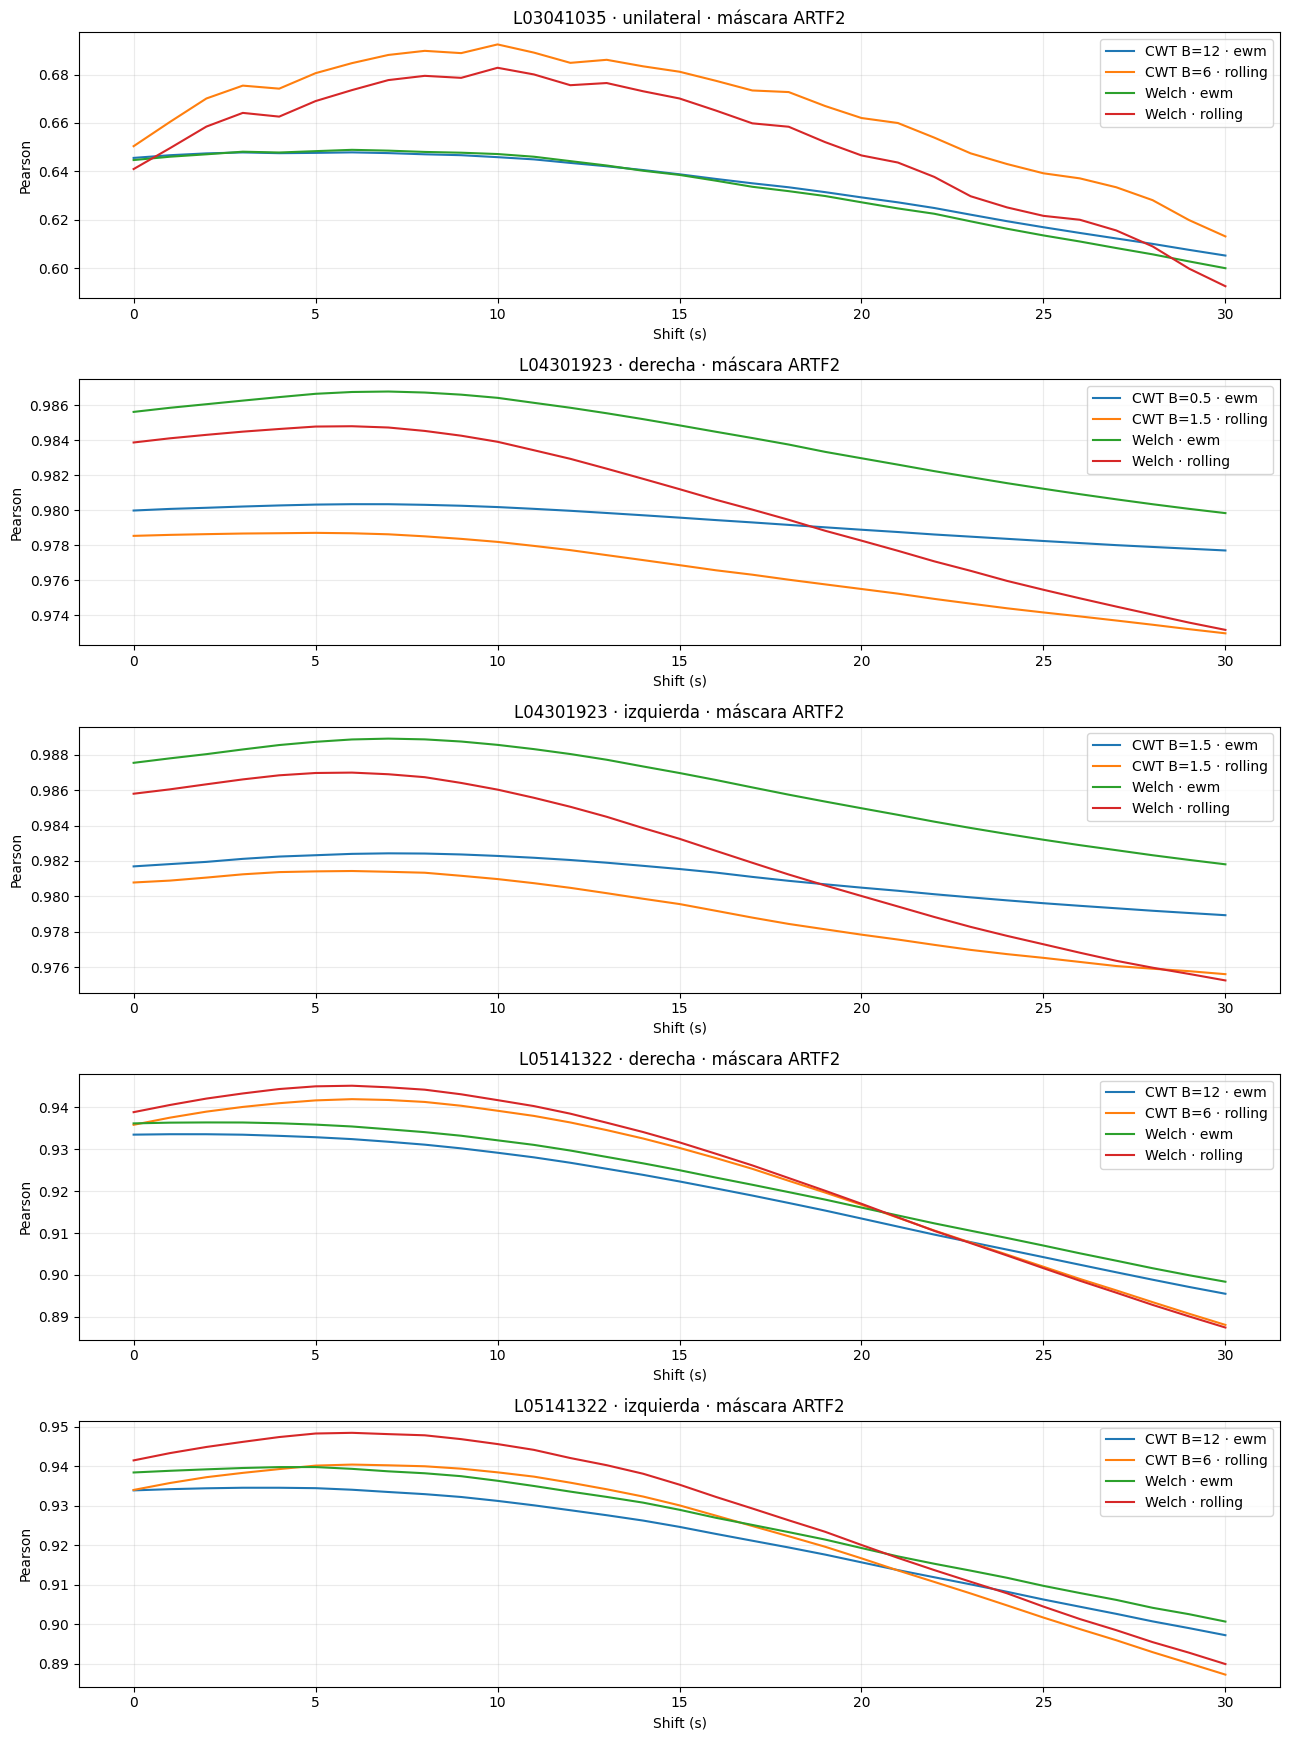

In [15]:
grupos = list(
    mejor_global[["registro", "lado"]]
    .itertuples(index=False, name=None)
)
fig, axes = plt.subplots(
    len(grupos),
    1,
    figsize=(13, 3.5 * len(grupos)),
    squeeze=False,
)

for fila, (registro, lado) in enumerate(grupos):
    subconjunto = df_resultados.loc[
        (df_resultados["registro"] == registro)
        & (df_resultados["lado"] == lado)
        & (df_resultados["mascara"] == "ARTF2")
    ]
    for (metodo, suavizado), datos in subconjunto.groupby(
        ["metodo_espectral", "suavizado"]
    ):
        if metodo == "CWT Morlet":
            ganador = ganadores.loc[
                (ganadores["registro"] == registro)
                & (ganadores["lado"] == lado)
                & (ganadores["metodo_espectral"] == metodo)
                & (ganadores["suavizado"] == suavizado)
                & (ganadores["mascara"] == "ARTF2")
            ].sort_values("Pearson", ascending=False).iloc[0]
            datos = datos.loc[
                datos["bandwidth_B"]
                == ganador["bandwidth_B"]
            ]
            etiqueta = (
                f"CWT B={ganador['bandwidth_B']:g} · {suavizado}"
            )
        else:
            etiqueta = f"Welch · {suavizado}"
        axes[fila, 0].plot(
            datos["shift_s"],
            datos["Pearson"],
            label=etiqueta,
        )
    axes[fila, 0].set_title(f"{registro} · {lado} · máscara ARTF2")
    axes[fila, 0].set_xlabel("Shift (s)")
    axes[fila, 0].set_ylabel("Pearson")
    axes[fila, 0].grid(alpha=0.25)
    axes[fila, 0].legend()

plt.tight_layout()
plt.show()

## Exportación de resultados

In [16]:
SALIDA = Path.cwd()
df_auditoria.to_csv(
    SALIDA / "auditoria_archivos_bis.csv",
    index=False,
)
df_flags.to_csv(
    SALIDA / "resumen_flags_artefacto.csv",
    index=False,
)
df_resultados.to_csv(
    SALIDA / "resultados_metodos_suavizados_artefactos.csv",
    index=False,
)
mejores.to_csv(
    SALIDA / "mejores_shifts_metodos_suavizados.csv",
    index=False,
)
ganadores.to_csv(
    SALIDA / "ganadores_metodos_suavizados.csv",
    index=False,
)
mejor_global.to_csv(
    SALIDA / "mejor_global_metodos_suavizados.csv",
    index=False,
)
resumen_macro.to_csv(
    SALIDA / "resumen_macro_metodos_suavizados.csv",
    index=False,
)

print("Tablas exportadas correctamente.")

Tablas exportadas correctamente.


## Resumen automático

In [17]:
rolling_gana_pearson = (
    comparacion_suavizados[
        "delta_Pearson_ewm_menos_rolling"
    ] < 0
).sum()
ewm_gana_pearson = (
    comparacion_suavizados[
        "delta_Pearson_ewm_menos_rolling"
    ] > 0
).sum()
artf_mejora_pearson = (
    comparacion_mascaras[
        "delta_Pearson_ARTF2_menos_base"
    ] > 0
).sum()
artf_mejora_rmse = (
    comparacion_mascaras[
        "delta_RMSE_ARTF2_menos_base"
    ] < 0
).sum()

print(
    f"Rolling obtiene mayor Pearson en "
    f"{rolling_gana_pearson} comparaciones."
)
print(
    f"EWM obtiene mayor Pearson en "
    f"{ewm_gana_pearson} comparaciones."
)
print(
    f"La máscara ARTF2 mejora Pearson en "
    f"{artf_mejora_pearson} comparaciones."
)
print(
    f"La máscara ARTF2 reduce RMSE en "
    f"{artf_mejora_rmse} comparaciones."
)
print()
display(mejor_global)

Rolling obtiene mayor Pearson en 12 comparaciones.
EWM obtiene mayor Pearson en 8 comparaciones.
La máscara ARTF2 mejora Pearson en 12 comparaciones.
La máscara ARTF2 reduce RMSE en 11 comparaciones.



,registro,lado,metodo_espectral,suavizado,mascara,bandwidth_B,modo,SpSmooth_s,shift_s,segundos_enmascarados,porcentaje_enmascarado,n,Pearson,MAE,RMSE,bias
0,L03041035,unilateral,Welch,rolling,base,NaN,unilateral,30,10,160,7.550731,116340,0.723813,3.720290,5.032721,2.957049
1,L04301923,derecha,Welch,ewm,ARTF2,NaN,bilateral,30,7,1095,15.208333,365880,0.986780,0.980167,1.414308,0.127008
2,L04301923,izquierda,Welch,ewm,ARTF2,NaN,bilateral,30,7,922,12.805556,376320,0.988906,0.917133,1.332604,0.104783
3,L05141322,derecha,Welch,rolling,base,NaN,bilateral,30,6,28,1.032448,160680,0.945502,1.746017,2.387310,0.873343
4,L05141322,izquierda,Welch,rolling,ARTF2,NaN,bilateral,30,6,877,32.337758,109440,0.948459,1.531735,2.150676,0.631689


## Orientación para la interpretación

La elección final no debe basarse únicamente en la combinación que maximiza
una métrica en un registro aislado. Se considerará más defendible la opción que:

1. Mantenga un comportamiento consistente entre registros y hemisferios.
2. Obtenga simultáneamente Pearson alto y MAE/RMSE bajos.
3. Respete el significado temporal de `SpSmooth`.
4. Utilice criterios de artefacto documentados por el fabricante.
5. No requiera una calibración dependiente del `.f_a`.

`Rolling` y `EWM` no representan exactamente la misma memoria temporal.
Rolling conserva únicamente los últimos `SpSmooth` segundos cronológicos,
mientras que EWM con `ignore_na=True` puede mantener información anterior a un
tramo artefactado. El notebook cuantifica esta diferencia para que la decisión
metodológica no dependa de una intuición o de un único registro.